# Vector Embeddings

Today the goal is to add vector embeddings for our chunks, ensuring that they will be usable for our RAG pipeline.

For lack of better instruction, we will use the sentence transformers package and look to other packages where uncertain.

In [1]:
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import json
from pathlib import Path
import numpy as np

root = Path(r"C:\Users\micro\Documents\ABTalksAI-Cohort")
json_path = root / "knowledge_base.jsonl"
jsonfile = open(json_path, "r", encoding="utf-8")

embeddings = []
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

new_json_path = root / "knowledge_base_embed.jsonl"

sections = []

with open(new_json_path, "w", encoding="utf-8") as file:
    for line in jsonfile:
        chunk = json.loads(line)
        text_data = chunk["id"]
        embedding = model.encode(text_data)
        print(embedding.shape)

        # add embeddings to jsonl
        embeddings.append(embedding)
        chunk["embeddings"] = embedding.tolist()
        file.write(json.dumps(chunk) + "\n")

        # sections variable reference
        sections.append(chunk["section"])
        

jsonfile.close()

all_embeddings = np.array(embeddings)
np.save(root / "embeddings.npy", all_embeddings)


c:\Users\micro\Documents\ABTalksAI-Cohort\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13013.23it/s]


(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)
(384,)


Next, we use PCA to reduce embeddings down to 3d and plot them!

to reference the `"sections"` variable we need to go back to the for loop

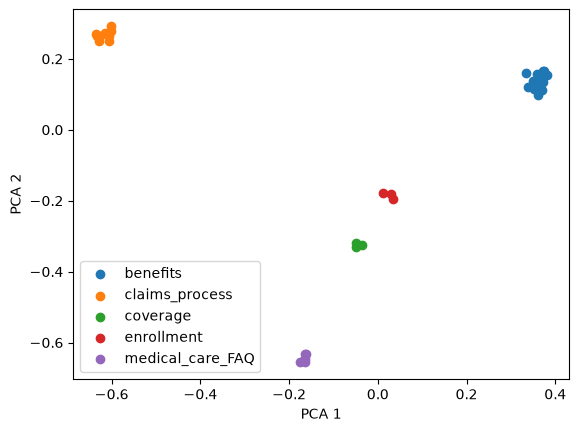

<Figure size 640x480 with 0 Axes>

In [2]:
from sklearn.decomposition import PCA

sections = np.array(sections)
plot = PCA(n_components=2).fit_transform(all_embeddings)

for section in np.unique(sections):
    mask = sections == section

    plt.scatter(
        plot[mask, 0],
        plot[mask, 1],
        label=section
    )

plt.legend()
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

plt.savefig(root / 'embeddings_2d.png', dpi=300)